# Ambimodal TS generation

This notebook shows how to generate an initial guess for an ambimodal TS (from *J. Am. Chem. Soc.* **148**, 8723–8735 (2026)), which is also a Formula-OOS case.

In [ ]:
import torch,os
from molop.config import molopconfig
from qcbot.utils import symbol_pos_to_xyz_file
from units.data import gen_dataset_from_smiles
from units.generate import load_model
from rdkit import Chem
from torch_geometric.data import DataLoader
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300, 300
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pt = Chem.GetPeriodicTable()
molopconfig.quiet()

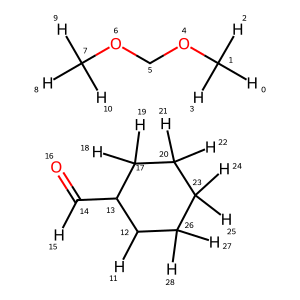

In [2]:
smiles = '[H]C([H])([H])OCOC([H])([H])[H].[H]C1C(C([H])=O)C([H])([H])C([H])([H])C([H])([H])C1([H])[H]'
reactive_atom_idx = [5,12]
Chem.MolFromSmiles(smiles,sanitize=False)

In [3]:
model_path = "../model_path/units_hiegnn"
args,model = load_model(model_path)

alphas2 [9.99990000e-01 9.99988000e-01 9.99982000e-01 ... 2.59676966e-05
 1.39959211e-05 1.00039959e-05]
gamma [-11.51291546 -11.33059532 -10.92513058 ...  10.55863126  11.17673063
  11.51251595]


In [ ]:
dataset = gen_dataset_from_smiles(None,[[smiles,[5,12]]]*10,args,charge=0,multi=1) # generate 10 samples for 1 reaction
dataloader = DataLoader(dataset, batch_size=min(16,len(dataset)), shuffle=False, num_workers=args.num_workers)

Processing...
Done!


In [23]:
tot_pred_final = []
for data in dataloader:
    data = data.to(device)
    x_traj,mol_atoms,node_mask = model.sample_traj(data,fix_noise=False,resample=False)
    pred_final = x_traj[-1]
    tot_pred_final.append(pred_final)

12it [00:00, 13.67it/s]

1000it [01:04, 15.46it/s]


In [25]:
os.makedirs("./ambimodalts",exist_ok=True)
for idx,pred_pos in enumerate(tot_pred_final[0]):
    atoms = dataset[0].mol_atoms
    symbols = [pt.GetElementSymbol(int(a)) for a in atoms]
    symbol_pos_to_xyz_file(symbols,pred_pos,f"./ambimodalts/gen_{idx}.xyz")

We chose `./ambimodalts/gen_8.xyz` for DFT optimization and quasi-classical molecular dynamics simulations. The optimized geometry is saved in `./ambimodalts/gen_8_opted.xyz`, and the MD results are saved in `./ambimodalts/traj-reactive.zip`.